In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import json
import pickle
import random
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix
)

SEEDS = [42, 123, 2024]

BASE_PROJECT = Path("/content/drive/MyDrive/New Jurnal Cross")

HC_DIR = BASE_PROJECT / "processed_intra_features_hc_noaug"
E2V_DIR = BASE_PROJECT / "processed_intra_features_e2v_plus_base"

OUT_DIR = BASE_PROJECT / "results_intra_cross_attention_fusion_plus_base"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["emodb", "ravdess", "resd"]

LABELS = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
]

ID_TO_LABEL = {i: label for i, label in enumerate(LABELS)}
LABEL_TO_ID = {label: i for i, label in ID_TO_LABEL.items()}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE:", DEVICE)
print("HC_DIR :", HC_DIR)
print("E2V_DIR:", E2V_DIR)
print("OUT_DIR:", OUT_DIR)

for ds in DATASETS:
    print("=" * 60)
    print(ds)
    print("HC exists :", (HC_DIR / ds).exists())
    print("E2V exists:", (E2V_DIR / ds).exists())

DEVICE: cuda
HC_DIR : /content/drive/MyDrive/New Jurnal Cross/processed_intra_features_hc_noaug
E2V_DIR: /content/drive/MyDrive/New Jurnal Cross/processed_intra_features_e2v_plus_base
OUT_DIR: /content/drive/MyDrive/New Jurnal Cross/results_intra_cross_attention_fusion_plus_base
emodb
HC exists : True
E2V exists: True
ravdess
HC exists : True
E2V exists: True
resd
HC exists : True
E2V exists: True


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "uar": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def make_report_df(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        labels=list(range(len(LABELS))),
        zero_division=0,
        output_dict=True
    )
    return pd.DataFrame(report).transpose()


def save_confusion_matrix_csv(cm, out_path):
    df_cm = pd.DataFrame(cm, index=LABELS, columns=LABELS)
    df_cm.to_csv(out_path, index=True)


def compute_class_weights(y_train, n_classes=6):
    counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)
    weights = counts.sum() / (n_classes * counts)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)

In [4]:
def load_paired_dataset(dataset_name, scale=True):
    hc_ds = HC_DIR / dataset_name
    e2v_ds = E2V_DIR / dataset_name

    # Handcrafted
    X_hc_train = np.load(hc_ds / "X_hc_train.npy").astype(np.float32)
    X_hc_val = np.load(hc_ds / "X_hc_val.npy").astype(np.float32)
    X_hc_test = np.load(hc_ds / "X_hc_test.npy").astype(np.float32)

    y_hc_train = np.load(hc_ds / "y_train.npy").astype(np.int64)
    y_hc_val = np.load(hc_ds / "y_val.npy").astype(np.int64)
    y_hc_test = np.load(hc_ds / "y_test.npy").astype(np.int64)

    meta_hc_train = pd.read_csv(hc_ds / "meta_train.csv")
    meta_hc_val = pd.read_csv(hc_ds / "meta_val.csv")
    meta_hc_test = pd.read_csv(hc_ds / "meta_test.csv")

    # emotion2vec
    X_e2v_train = np.load(e2v_ds / "X_e2v_train.npy").astype(np.float32)
    X_e2v_val = np.load(e2v_ds / "X_e2v_val.npy").astype(np.float32)
    X_e2v_test = np.load(e2v_ds / "X_e2v_test.npy").astype(np.float32)

    y_e2v_train = np.load(e2v_ds / "y_train.npy").astype(np.int64)
    y_e2v_val = np.load(e2v_ds / "y_val.npy").astype(np.int64)
    y_e2v_test = np.load(e2v_ds / "y_test.npy").astype(np.int64)

    meta_e2v_train = pd.read_csv(e2v_ds / "meta_train.csv")
    meta_e2v_val = pd.read_csv(e2v_ds / "meta_val.csv")
    meta_e2v_test = pd.read_csv(e2v_ds / "meta_test.csv")

    # Safety checks
    assert X_hc_train.shape[0] == X_e2v_train.shape[0], "train N mismatch"
    assert X_hc_val.shape[0] == X_e2v_val.shape[0], "val N mismatch"
    assert X_hc_test.shape[0] == X_e2v_test.shape[0], "test N mismatch"

    assert np.array_equal(y_hc_train, y_e2v_train), "train labels mismatch"
    assert np.array_equal(y_hc_val, y_e2v_val), "val labels mismatch"
    assert np.array_equal(y_hc_test, y_e2v_test), "test labels mismatch"

    for split_name, meta_hc, meta_e2v in [
        ("train", meta_hc_train, meta_e2v_train),
        ("val", meta_hc_val, meta_e2v_val),
        ("test", meta_hc_test, meta_e2v_test),
    ]:
        if "uid" in meta_hc.columns and "uid" in meta_e2v.columns:
            if not meta_hc["uid"].astype(str).equals(meta_e2v["uid"].astype(str)):
                raise ValueError(f"UID mismatch in {dataset_name} {split_name}")

    scaler_hc = None
    scaler_e2v = None

    if scale:
        scaler_hc = StandardScaler()
        X_hc_train = scaler_hc.fit_transform(X_hc_train).astype(np.float32)
        X_hc_val = scaler_hc.transform(X_hc_val).astype(np.float32)
        X_hc_test = scaler_hc.transform(X_hc_test).astype(np.float32)

        scaler_e2v = StandardScaler()
        X_e2v_train = scaler_e2v.fit_transform(X_e2v_train).astype(np.float32)
        X_e2v_val = scaler_e2v.transform(X_e2v_val).astype(np.float32)
        X_e2v_test = scaler_e2v.transform(X_e2v_test).astype(np.float32)

    return {
        "X_hc_train": X_hc_train,
        "X_hc_val": X_hc_val,
        "X_hc_test": X_hc_test,

        "X_e2v_train": X_e2v_train,
        "X_e2v_val": X_e2v_val,
        "X_e2v_test": X_e2v_test,

        "y_train": y_hc_train,
        "y_val": y_hc_val,
        "y_test": y_hc_test,

        "meta_train": meta_hc_train,
        "meta_val": meta_hc_val,
        "meta_test": meta_hc_test,

        "scaler_hc": scaler_hc,
        "scaler_e2v": scaler_e2v,

        "hc_dim": X_hc_train.shape[1],
        "e2v_dim": X_e2v_train.shape[1],
    }

In [5]:
class PairedFeatureDataset(Dataset):
    def __init__(self, X_e2v, X_hc, y):
        self.X_e2v = torch.tensor(X_e2v, dtype=torch.float32)
        self.X_hc = torch.tensor(X_hc, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_e2v[idx], self.X_hc[idx], self.y[idx]


def make_paired_loader(X_e2v, X_hc, y, batch_size=32, shuffle=False):
    dataset = PairedFeatureDataset(X_e2v, X_hc, y)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False
    )

In [6]:
for ds in DATASETS:
    data = load_paired_dataset(ds, scale=True)

    print("=" * 80)
    print(ds.upper())
    print("E2V dim:", data["e2v_dim"])
    print("HC dim :", data["hc_dim"])

    print("Train E2V:", data["X_e2v_train"].shape)
    print("Train HC :", data["X_hc_train"].shape)
    print("Val E2V  :", data["X_e2v_val"].shape)
    print("Val HC   :", data["X_hc_val"].shape)
    print("Test E2V :", data["X_e2v_test"].shape)
    print("Test HC  :", data["X_hc_test"].shape)

    print("NaN E2V train:", np.isnan(data["X_e2v_train"]).any())
    print("NaN HC train :", np.isnan(data["X_hc_train"]).any())

EMODB
E2V dim: 768
HC dim : 548
Train E2V: (498, 768)
Train HC : (498, 548)
Val E2V  : (71, 768)
Val HC   : (71, 548)
Test E2V : (149, 768)
Test HC  : (149, 548)
NaN E2V train: False
NaN HC train : False
RAVDESS
E2V dim: 768
HC dim : 548
Train E2V: (704, 768)
Train HC : (704, 548)
Val E2V  : (176, 768)
Val HC   : (176, 548)
Test E2V : (176, 768)
Test HC  : (176, 548)
NaN E2V train: False
NaN HC train : False
RESD
E2V dim: 768
HC dim : 548
Train E2V: (873, 768)
Train HC : (873, 548)
Val E2V  : (186, 768)
Val HC   : (186, 548)
Test E2V : (139, 768)
Test HC  : (139, 548)
NaN E2V train: False
NaN HC train : False


In [7]:
class CrossAttentionFusionModel(nn.Module):
    def __init__(
        self,
        e2v_dim=768,
        hc_dim=548,
        d_model=256,
        num_heads=4,
        num_classes=6,
        dropout=0.30
    ):
        super().__init__()

        self.e2v_proj = nn.Sequential(
            nn.Linear(e2v_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.hc_proj = nn.Sequential(
            nn.Linear(hc_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.e2v_to_hc_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.hc_to_e2v_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm_e = nn.LayerNorm(d_model)
        self.norm_h = nn.LayerNorm(d_model)

        # Fusion components:
        # e, h, e_att, h_att, |e-h|, e*h = 6 * d_model
        fusion_dim = d_model * 6

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, num_classes)
        )

    def forward(self, x_e2v, x_hc, return_attention=False):
        # [B, D] → [B, d_model]
        e = self.e2v_proj(x_e2v)
        h = self.hc_proj(x_hc)

        # MultiheadAttention expects sequence.
        # Kita gunakan 1 token per modalitas: [B, 1, d_model]
        e_seq = e.unsqueeze(1)
        h_seq = h.unsqueeze(1)

        # emotion2vec attends to handcrafted
        e_att_seq, attn_eh = self.e2v_to_hc_attn(
            query=e_seq,
            key=h_seq,
            value=h_seq,
            need_weights=True
        )

        # handcrafted attends to emotion2vec
        h_att_seq, attn_he = self.hc_to_e2v_attn(
            query=h_seq,
            key=e_seq,
            value=e_seq,
            need_weights=True
        )

        e_att = e_att_seq.squeeze(1)
        h_att = h_att_seq.squeeze(1)

        # Residual + norm
        e_fused = self.norm_e(e + e_att)
        h_fused = self.norm_h(h + h_att)

        diff = torch.abs(e_fused - h_fused)
        prod = e_fused * h_fused

        fusion = torch.cat(
            [
                e_fused,
                h_fused,
                e_att,
                h_att,
                diff,
                prod
            ],
            dim=1
        )

        logits = self.classifier(fusion)

        if return_attention:
            return logits, attn_eh, attn_he

        return logits

In [8]:
!pip -q install torchinfo

from torchinfo import summary

dummy_model = CrossAttentionFusionModel(
    e2v_dim=768,
    hc_dim=548,
    d_model=256,
    num_heads=4,
    num_classes=6,
    dropout=0.30
).to(DEVICE)

summary(
    dummy_model,
    input_data=[
        torch.randn(32, 768).to(DEVICE),
        torch.randn(32, 548).to(DEVICE)
    ],
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=4
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
CrossAttentionFusionModel                [32, 768]                 [32, 6]                   --                        True
├─Sequential: 1-1                        [32, 768]                 [32, 256]                 --                        True
│    └─Linear: 2-1                       [32, 768]                 [32, 256]                 196,864                   True
│    └─LayerNorm: 2-2                    [32, 256]                 [32, 256]                 512                       True
│    └─ReLU: 2-3                         [32, 256]                 [32, 256]                 --                        --
│    └─Dropout: 2-4                      [32, 256]                 [32, 256]                 --                        --
├─Sequential: 1-2                        [32, 548]                 [32, 256]                 --                        True
│    └─

In [9]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for x_e2v, x_hc, y_batch in loader:
        x_e2v = x_e2v.to(DEVICE)
        x_hc = x_hc.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(x_e2v, x_hc)
            loss = criterion(logits, y_batch)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        total_loss += loss.item() * x_e2v.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(y_batch.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(np.array(all_targets), np.array(all_preds))

    return avg_loss, metrics, np.array(all_targets), np.array(all_preds)


@torch.no_grad()
def predict_model(model, loader):
    model.eval()

    all_preds = []
    all_targets = []
    all_probs = []

    for x_e2v, x_hc, y_batch in loader:
        x_e2v = x_e2v.to(DEVICE)
        x_hc = x_hc.to(DEVICE)

        logits = model(x_e2v, x_hc)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_targets.extend(y_batch.numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

    return (
        np.array(all_targets),
        np.array(all_preds),
        np.array(all_probs)
    )

In [10]:
def train_eval_cross_attention(
    dataset_name,
    seed,
    batch_size=32,
    lr=5e-4,
    weight_decay=1e-4,
    max_epochs=150,
    patience=20,
    scale=True,
    d_model=256,
    num_heads=4,
    dropout=0.30
):
    set_seed(seed)

    data = load_paired_dataset(dataset_name, scale=scale)

    train_loader = make_paired_loader(
        data["X_e2v_train"],
        data["X_hc_train"],
        data["y_train"],
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = make_paired_loader(
        data["X_e2v_val"],
        data["X_hc_val"],
        data["y_val"],
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = make_paired_loader(
        data["X_e2v_test"],
        data["X_hc_test"],
        data["y_test"],
        batch_size=batch_size,
        shuffle=False
    )

    num_classes = len(LABELS)

    model = CrossAttentionFusionModel(
        e2v_dim=data["e2v_dim"],
        hc_dim=data["hc_dim"],
        d_model=d_model,
        num_heads=num_heads,
        num_classes=num_classes,
        dropout=dropout
    ).to(DEVICE)

    class_weights = compute_class_weights(data["y_train"], n_classes=num_classes).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5
    )

    best_val_macro_f1 = -1.0
    best_epoch = -1
    best_state = None
    no_improve = 0

    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss, train_metrics, _, _ = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer
        )

        val_loss, val_metrics, _, _ = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None
        )

        scheduler.step(val_metrics["macro_f1"])

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "lr": optimizer.param_groups[0]["lr"]
        }
        history.append(row)

        current = val_metrics["macro_f1"]

        if current > best_val_macro_f1:
            best_val_macro_f1 = current
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"[{dataset_name} | seed={seed}] "
                f"Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
                f"best={best_val_macro_f1:.4f}"
            )

        if no_improve >= patience:
            print(
                f"[{dataset_name} | seed={seed}] Early stopping at epoch {epoch}. "
                f"Best epoch: {best_epoch}, best val macro-F1: {best_val_macro_f1:.4f}"
            )
            break

    model.load_state_dict(best_state)

    y_val_true, y_val_pred, y_val_prob = predict_model(model, val_loader)
    y_test_true, y_test_pred, y_test_prob = predict_model(model, test_loader)

    val_metrics = compute_metrics(y_val_true, y_val_pred)
    test_metrics = compute_metrics(y_test_true, y_test_pred)

    run_dir = OUT_DIR / dataset_name / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    torch.save(model.state_dict(), run_dir / "cross_attention_fusion_model.pt")

    if data["scaler_hc"] is not None:
        with open(run_dir / "scaler_hc.pkl", "wb") as f:
            pickle.dump(data["scaler_hc"], f)

    if data["scaler_e2v"] is not None:
        with open(run_dir / "scaler_e2v.pkl", "wb") as f:
            pickle.dump(data["scaler_e2v"], f)

    with open(run_dir / "training_config.json", "w") as f:
        json.dump({
            "dataset": dataset_name,
            "seed": seed,
            "batch_size": batch_size,
            "lr": lr,
            "weight_decay": weight_decay,
            "max_epochs": max_epochs,
            "patience": patience,
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro_f1,
            "e2v_dim": data["e2v_dim"],
            "hc_dim": data["hc_dim"],
            "d_model": d_model,
            "num_heads": num_heads,
            "dropout": dropout,
            "num_classes": num_classes,
            "model": "CrossAttentionFusionModel",
            "class_weighted_loss": True,
            "scale": scale,
            "fusion_type": "bidirectional_modality_level_cross_attention"
        }, f, indent=2)

    pd.DataFrame(history).to_csv(run_dir / "training_history.csv", index=False)

    pd.DataFrame([{
        "dataset": dataset_name,
        "seed": seed,
        "split": "val",
        "best_epoch": best_epoch,
        **val_metrics
    }]).to_csv(run_dir / "val_metrics.csv", index=False)

    pd.DataFrame([{
        "dataset": dataset_name,
        "seed": seed,
        "split": "test",
        "best_epoch": best_epoch,
        **test_metrics
    }]).to_csv(run_dir / "test_metrics.csv", index=False)

    make_report_df(y_val_true, y_val_pred).to_csv(run_dir / "val_classification_report.csv")
    make_report_df(y_test_true, y_test_pred).to_csv(run_dir / "test_classification_report.csv")

    cm_val = confusion_matrix(y_val_true, y_val_pred, labels=list(range(len(LABELS))))
    cm_test = confusion_matrix(y_test_true, y_test_pred, labels=list(range(len(LABELS))))

    save_confusion_matrix_csv(cm_val, run_dir / "val_confusion_matrix.csv")
    save_confusion_matrix_csv(cm_test, run_dir / "test_confusion_matrix.csv")

    pred_val_df = data["meta_val"].copy()
    pred_val_df["y_true"] = y_val_true
    pred_val_df["y_pred"] = y_val_pred
    pred_val_df["true_label"] = [ID_TO_LABEL[i] for i in y_val_true]
    pred_val_df["pred_label"] = [ID_TO_LABEL[i] for i in y_val_pred]

    for i, label in enumerate(LABELS):
        pred_val_df[f"prob_{label}"] = y_val_prob[:, i]

    pred_val_df.to_csv(run_dir / "val_predictions.csv", index=False)

    pred_test_df = data["meta_test"].copy()
    pred_test_df["y_true"] = y_test_true
    pred_test_df["y_pred"] = y_test_pred
    pred_test_df["true_label"] = [ID_TO_LABEL[i] for i in y_test_true]
    pred_test_df["pred_label"] = [ID_TO_LABEL[i] for i in y_test_pred]

    for i, label in enumerate(LABELS):
        pred_test_df[f"prob_{label}"] = y_test_prob[:, i]

    pred_test_df.to_csv(run_dir / "test_predictions.csv", index=False)

    row_val = {
        "dataset": dataset_name,
        "seed": seed,
        "split": "val",
        "best_epoch": best_epoch,
        **val_metrics
    }

    row_test = {
        "dataset": dataset_name,
        "seed": seed,
        "split": "test",
        "best_epoch": best_epoch,
        **test_metrics
    }

    return row_val, row_test

In [11]:
all_rows = []

for dataset_name in DATASETS:
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    for seed in SEEDS:
        print(f"\nTraining cross-attention fusion | dataset={dataset_name} | seed={seed}")

        row_val, row_test = train_eval_cross_attention(
            dataset_name=dataset_name,
            seed=seed,
            batch_size=32,
            lr=5e-4,
            weight_decay=1e-4,
            max_epochs=150,
            patience=20,
            scale=True,
            d_model=256,
            num_heads=4,
            dropout=0.30
        )

        all_rows.append(row_val)
        all_rows.append(row_test)

        print("VAL :", {k: round(v, 4) for k, v in row_val.items() if isinstance(v, float)})
        print("TEST:", {k: round(v, 4) for k, v in row_test.items() if isinstance(v, float)})

results = pd.DataFrame(all_rows)
results.to_csv(OUT_DIR / "all_seed_results.csv", index=False)

display(results)
print("Saved:", OUT_DIR / "all_seed_results.csv")

DATASET: EMODB

Training cross-attention fusion | dataset=emodb | seed=42
[emodb | seed=42] Epoch 001 | train_loss=0.8598 | val_loss=0.9413 | val_macro_f1=0.6564 | best=0.6564
[emodb | seed=42] Epoch 010 | train_loss=0.0360 | val_loss=1.0351 | val_macro_f1=0.7318 | best=0.8017
[emodb | seed=42] Epoch 020 | train_loss=0.0065 | val_loss=1.4494 | val_macro_f1=0.7036 | best=0.8017
[emodb | seed=42] Early stopping at epoch 28. Best epoch: 8, best val macro-F1: 0.8017
VAL : {'accuracy': 0.8028, 'macro_f1': 0.8017, 'weighted_f1': 0.8005, 'uar': 0.8096}
TEST: {'accuracy': 0.9195, 'macro_f1': 0.9195, 'weighted_f1': 0.9194, 'uar': 0.9175}

Training cross-attention fusion | dataset=emodb | seed=123
[emodb | seed=123] Epoch 001 | train_loss=0.8998 | val_loss=0.9142 | val_macro_f1=0.6973 | best=0.6973
[emodb | seed=123] Epoch 010 | train_loss=0.0283 | val_loss=1.6654 | val_macro_f1=0.6888 | best=0.7750
[emodb | seed=123] Epoch 020 | train_loss=0.0063 | val_loss=1.5267 | val_macro_f1=0.7111 | best=0

,dataset,seed,split,best_epoch,accuracy,macro_f1,weighted_f1,uar
0,emodb,42,val,8,0.802817,0.801654,0.800494,0.809635
1,emodb,42,test,8,0.919463,0.919465,0.919385,0.917499
2,emodb,123,val,5,0.788732,0.775013,0.773968,0.794678
3,emodb,123,test,5,0.892617,0.893165,0.893231,0.888459
4,emodb,2024,val,2,0.774648,0.769742,0.768374,0.782925
5,emodb,2024,test,2,0.899329,0.899553,0.899366,0.896035
6,ravdess,42,val,2,0.914773,0.908140,0.916988,0.916667
7,ravdess,42,test,2,0.965909,0.951849,0.964307,0.942708
8,ravdess,123,val,6,0.914773,0.909097,0.917150,0.921875
9,ravdess,123,test,6,0.977273,0.973334,0.976970,0.968750


Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_cross_attention_fusion_plus_base/all_seed_results.csv


In [12]:
metrics = ["accuracy", "macro_f1", "weighted_f1", "uar"]

summary_rows = []

for dataset_name in DATASETS:
    for split in ["val", "test"]:
        sub = results[
            (results["dataset"] == dataset_name) &
            (results["split"] == split)
        ]

        row = {
            "dataset": dataset_name,
            "split": split,
            "n_seeds": len(sub),
            "best_epoch_mean": sub["best_epoch"].mean(),
            "best_epoch_std": sub["best_epoch"].std(ddof=1),
        }

        for metric in metrics:
            row[f"{metric}_mean"] = sub[metric].mean()
            row[f"{metric}_std"] = sub[metric].std(ddof=1)

        summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT_DIR / "summary_mean_std.csv", index=False)

display(summary)
print("Saved:", OUT_DIR / "summary_mean_std.csv")

,dataset,split,n_seeds,best_epoch_mean,best_epoch_std,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,uar_mean,uar_std
0,emodb,val,3,5.0,3.000000,0.788732,0.014085,0.782137,0.017107,0.780945,0.017159,0.795746,0.013387
1,emodb,test,3,5.0,3.000000,0.903803,0.013971,0.904061,0.013717,0.903994,0.013677,0.900664,0.015064
2,ravdess,val,3,8.0,7.211103,0.916667,0.003280,0.910128,0.002657,0.919190,0.003674,0.921875,0.005208
3,ravdess,test,3,8.0,7.211103,0.973485,0.006561,0.966198,0.012427,0.972777,0.007336,0.960069,0.015035
4,resd,val,3,1.0,0.000000,0.607527,0.014224,0.599585,0.012932,0.599504,0.011868,0.608304,0.013978
5,resd,test,3,1.0,0.000000,0.592326,0.014976,0.582661,0.005967,0.607011,0.004833,0.598851,0.009951


Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_cross_attention_fusion_plus_base/summary_mean_std.csv


In [13]:
def mean_std_str(mean, std, scale=100):
    return f"{mean * scale:.2f} ± {std * scale:.2f}"


paper_rows = []

for dataset_name in DATASETS:
    sub = summary[
        (summary["dataset"] == dataset_name) &
        (summary["split"] == "test")
    ].iloc[0]

    paper_rows.append({
        "Dataset": dataset_name.upper(),
        "Accuracy": mean_std_str(sub["accuracy_mean"], sub["accuracy_std"]),
        "UAR": mean_std_str(sub["uar_mean"], sub["uar_std"]),
        "Macro-F1": mean_std_str(sub["macro_f1_mean"], sub["macro_f1_std"]),
        "Weighted-F1": mean_std_str(sub["weighted_f1_mean"], sub["weighted_f1_std"]),
        "Best Epoch": f"{sub['best_epoch_mean']:.1f} ± {sub['best_epoch_std']:.1f}",
    })

paper_table = pd.DataFrame(paper_rows)
paper_table.to_csv(OUT_DIR / "paper_table_test_mean_std.csv", index=False)

display(paper_table)
print("Saved:", OUT_DIR / "paper_table_test_mean_std.csv")

,Dataset,Accuracy,UAR,Macro-F1,Weighted-F1,Best Epoch
0,EMODB,90.38 ± 1.40,90.07 ± 1.51,90.41 ± 1.37,90.40 ± 1.37,5.0 ± 3.0
1,RAVDESS,97.35 ± 0.66,96.01 ± 1.50,96.62 ± 1.24,97.28 ± 0.73,8.0 ± 7.2
2,RESD,59.23 ± 1.50,59.89 ± 1.00,58.27 ± 0.60,60.70 ± 0.48,1.0 ± 0.0


Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_cross_attention_fusion_plus_base/paper_table_test_mean_std.csv


In [14]:
per_class_rows = []

for dataset_name in DATASETS:
    for seed in SEEDS:
        report_path = OUT_DIR / dataset_name / f"seed_{seed}" / "test_classification_report.csv"
        report = pd.read_csv(report_path, index_col=0)

        for label in LABELS:
            per_class_rows.append({
                "dataset": dataset_name,
                "seed": seed,
                "class": label,
                "precision": report.loc[label, "precision"],
                "recall": report.loc[label, "recall"],
                "f1": report.loc[label, "f1-score"],
                "support": report.loc[label, "support"],
            })

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(OUT_DIR / "per_class_test_all_seeds.csv", index=False)

per_class_summary = (
    per_class_df
    .groupby(["dataset", "class"])
    .agg(
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        support_mean=("support", "mean"),
    )
    .reset_index()
)

per_class_summary.to_csv(OUT_DIR / "per_class_test_summary_mean_std.csv", index=False)

display(per_class_summary)
print("Saved:", OUT_DIR / "per_class_test_summary_mean_std.csv")

,dataset,class,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,support_mean
0,emodb,angry,0.944061,0.018581,0.965517,0.000000,0.954607,0.009448,29.0
1,emodb,disgust,0.984848,0.026243,0.924242,0.026243,0.953102,0.001250,22.0
2,emodb,fear,0.869565,0.000000,0.800000,0.000000,0.833333,0.000000,25.0
3,emodb,happy,0.915362,0.004016,0.902778,0.048113,0.908670,0.026072,24.0
4,emodb,neutral,0.966583,0.029048,0.848485,0.052486,0.902760,0.026201,22.0
5,emodb,sad,0.797098,0.037853,0.962963,0.000000,0.871892,0.022506,27.0
6,ravdess,angry,1.000000,0.000000,0.947917,0.018042,0.973204,0.009460,32.0
7,ravdess,disgust,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,32.0
8,ravdess,fear,0.989899,0.017495,1.000000,0.000000,0.994872,0.008882,32.0
9,ravdess,happy,0.960190,0.016466,1.000000,0.000000,0.979643,0.008613,32.0


Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_cross_attention_fusion_plus_base/per_class_test_summary_mean_std.csv


In [15]:
for dataset_name in DATASETS:
    cms = []

    for seed in SEEDS:
        cm_path = OUT_DIR / dataset_name / f"seed_{seed}" / "test_confusion_matrix.csv"
        cm = pd.read_csv(cm_path, index_col=0).values
        cms.append(cm)

    cm_mean = np.mean(cms, axis=0)
    cm_std = np.std(cms, axis=0, ddof=1)

    cm_mean_df = pd.DataFrame(cm_mean, index=LABELS, columns=LABELS)
    cm_std_df = pd.DataFrame(cm_std, index=LABELS, columns=LABELS)

    ds_out = OUT_DIR / dataset_name
    cm_mean_df.to_csv(ds_out / "test_confusion_matrix_mean.csv")
    cm_std_df.to_csv(ds_out / "test_confusion_matrix_std.csv")

    print("=" * 80)
    print(dataset_name.upper())
    print("Mean confusion matrix:")
    display(cm_mean_df.round(2))

    print("Std confusion matrix:")
    display(cm_std_df.round(2))

EMODB
Mean confusion matrix:


,angry,disgust,fear,happy,neutral,sad
angry,28.00,0.00,0.00,1.00,0.00,0.00
disgust,0.00,20.33,1.00,0.00,0.00,0.67
fear,0.00,0.00,20.00,1.00,0.67,3.33
happy,1.67,0.00,0.67,21.67,0.00,0.00
neutral,0.00,0.33,0.33,0.00,18.67,2.67
sad,0.00,0.00,1.00,0.00,0.00,26.00


Std confusion matrix:


,angry,disgust,fear,happy,neutral,sad
angry,0.00,0.00,0.00,0.00,0.00,0.00
disgust,0.00,0.58,0.00,0.00,0.00,0.58
fear,0.00,0.00,0.00,0.00,0.58,0.58
happy,0.58,0.00,0.58,1.15,0.00,0.00
neutral,0.00,0.58,0.58,0.00,1.15,1.53
sad,0.00,0.00,0.00,0.00,0.00,0.00


RAVDESS
Mean confusion matrix:


...

,angry,disgust,fear,happy,neutral,sad
angry,0.58,0.0,0.58,0.58,0.00,0.00
disgust,0.00,0.0,0.00,0.00,0.00,0.00
fear,0.00,0.0,0.00,0.00,0.00,0.00
happy,0.00,0.0,0.00,0.00,0.00,0.00
neutral,0.00,0.0,0.00,0.00,1.73,1.73
sad,0.00,0.0,0.00,0.00,0.00,0.00


RESD
Mean confusion matrix:


,angry,disgust,fear,happy,neutral,sad
angry,19.33,5.33,0.0,6.67,0.33,2.33
disgust,0.00,7.00,1.0,2.00,1.00,4.00
fear,0.00,5.00,11.0,0.00,3.33,9.67
happy,0.00,0.67,0.0,20.33,0.00,2.00
neutral,0.00,1.33,0.0,1.67,13.67,3.33
sad,0.33,4.00,0.0,0.67,2.00,11.00


Std confusion matrix:


,angry,disgust,fear,happy,neutral,sad
angry,0.58,4.93,0.0,4.04,0.58,0.58
disgust,0.00,1.00,0.0,1.00,0.00,0.00
fear,0.00,0.00,1.0,0.00,1.15,1.53
happy,0.00,0.58,0.0,1.15,0.00,1.00
neutral,0.00,0.58,0.0,0.58,0.58,0.58
sad,0.58,1.73,0.0,0.58,1.00,0.00


In [16]:
SVM_DIR = BASE_PROJECT / "results_intra_handcrafted_svm"
HC_MLP_DIR = BASE_PROJECT / "results_intra_handcrafted_mlp"
E2V_MLP_DIR = BASE_PROJECT / "results_intra_emotion2vec_mlp_plus_base"
CONCAT_DIR = BASE_PROJECT / "results_intra_concat_fusion_mlp_plus_base"
XATTN_DIR = BASE_PROJECT / "results_intra_cross_attention_fusion_plus_base"

svm_summary = pd.read_csv(SVM_DIR / "summary_mean_std.csv")
hc_mlp_summary = pd.read_csv(HC_MLP_DIR / "summary_mean_std.csv")
e2v_summary = pd.read_csv(E2V_MLP_DIR / "summary_mean_std.csv")
concat_summary = pd.read_csv(CONCAT_DIR / "summary_mean_std.csv")
xattn_summary = pd.read_csv(XATTN_DIR / "summary_mean_std.csv")

svm_test = svm_summary[svm_summary["split"] == "test"].copy()
hc_mlp_test = hc_mlp_summary[hc_mlp_summary["split"] == "test"].copy()
e2v_test = e2v_summary[e2v_summary["split"] == "test"].copy()
concat_test = concat_summary[concat_summary["split"] == "test"].copy()
xattn_test = xattn_summary[xattn_summary["split"] == "test"].copy()

svm_test["model"] = "Handcrafted SVM-RBF"
hc_mlp_test["model"] = "Handcrafted MLP"
e2v_test["model"] = "emotion2vec MLP"
concat_test["model"] = "Concat Fusion MLP"
xattn_test["model"] = "Cross-Attention Fusion"

compare = pd.concat(
    [
        svm_test,
        hc_mlp_test,
        e2v_test,
        concat_test,
        xattn_test
    ],
    ignore_index=True
)

cols = [
    "model",
    "dataset",
    "accuracy_mean",
    "accuracy_std",
    "uar_mean",
    "uar_std",
    "macro_f1_mean",
    "macro_f1_std",
    "weighted_f1_mean",
    "weighted_f1_std",
]

compare = compare[cols]
compare.to_csv(XATTN_DIR / "compare_all_intra_test.csv", index=False)

display(compare)
print("Saved:", XATTN_DIR / "compare_all_intra_test.csv")

,model,dataset,accuracy_mean,accuracy_std,uar_mean,uar_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,Handcrafted SVM-RBF,emodb,0.765101,0.000000e+00,0.771862,0.000000,0.770845,0.000000,0.766550,0.000000
1,Handcrafted SVM-RBF,ravdess,0.585227,0.000000e+00,0.572917,0.000000,0.562632,0.000000,0.575213,0.000000
2,Handcrafted SVM-RBF,resd,0.230216,0.000000e+00,0.216041,0.000000,0.177384,0.000000,0.201610,0.000000
3,Handcrafted MLP,emodb,0.722595,5.125924e-02,0.722497,0.057131,0.724663,0.053999,0.723408,0.052484
4,Handcrafted MLP,ravdess,0.564394,3.280399e-03,0.576389,0.003007,0.556696,0.007691,0.556044,0.004402
5,Handcrafted MLP,resd,0.213429,3.244065e-02,0.205268,0.026294,0.208880,0.041376,0.228542,0.040862
6,emotion2vec MLP,emodb,0.914989,1.397091e-02,0.914272,0.015576,0.915618,0.014075,0.914662,0.013859
7,emotion2vec MLP,ravdess,0.977273,1.359740e-16,0.968750,0.000000,0.973412,0.000000,0.977055,0.000000
8,emotion2vec MLP,resd,0.565947,1.497601e-02,0.567849,0.019836,0.546025,0.017867,0.566678,0.015246
9,Concat Fusion MLP,emodb,0.932886,1.162450e-02,0.932959,0.011840,0.934209,0.011421,0.933224,0.011423


Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_cross_attention_fusion_plus_base/compare_all_intra_test.csv


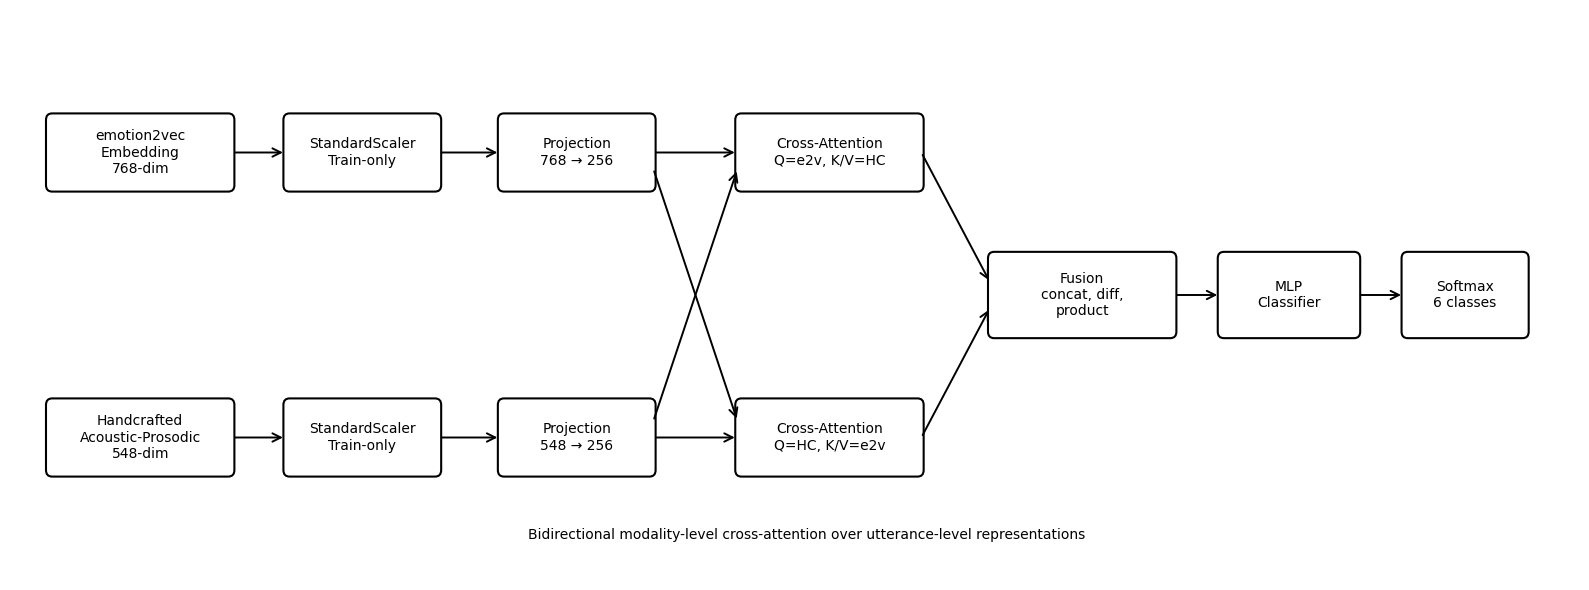

Saved: /content/drive/MyDrive/New Jurnal Cross/results_intra_cross_attention_fusion_plus_base/cross_attention_fusion_architecture.png


In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def draw_cross_attention_architecture(save_path=None):
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.set_xlim(0, 18)
    ax.set_ylim(0, 7)
    ax.axis("off")

    def box(x, y, w, h, text, fontsize=10):
        rect = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.03,rounding_size=0.08",
            linewidth=1.5,
            edgecolor="black",
            facecolor="white"
        )
        ax.add_patch(rect)
        ax.text(
            x + w / 2,
            y + h / 2,
            text,
            ha="center",
            va="center",
            fontsize=fontsize
        )

    def arrow(x1, y1, x2, y2):
        arr = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.4,
            color="black"
        )
        ax.add_patch(arr)

    # Inputs
    box(0.5, 4.8, 2.4, 0.9, "emotion2vec\nEmbedding\n768-dim")
    box(0.5, 1.3, 2.4, 0.9, "Handcrafted\nAcoustic-Prosodic\n548-dim")

    # Scaling
    box(3.6, 4.8, 2.0, 0.9, "StandardScaler\nTrain-only")
    box(3.6, 1.3, 2.0, 0.9, "StandardScaler\nTrain-only")

    # Projection
    box(6.4, 4.8, 2.0, 0.9, "Projection\n768 → 256")
    box(6.4, 1.3, 2.0, 0.9, "Projection\n548 → 256")

    # Cross attention
    box(9.5, 4.8, 2.4, 0.9, "Cross-Attention\nQ=e2v, K/V=HC")
    box(9.5, 1.3, 2.4, 0.9, "Cross-Attention\nQ=HC, K/V=e2v")

    # Fusion
    box(12.8, 3.0, 2.4, 1.0, "Fusion\nconcat, diff,\nproduct")

    # Classifier
    box(15.8, 3.0, 1.8, 1.0, "MLP\nClassifier")
    box(18.2, 3.0, 1.6, 1.0, "Softmax\n6 classes")

    ax.set_xlim(0, 20.5)

    # Arrows
    arrow(2.9, 5.25, 3.6, 5.25)
    arrow(2.9, 1.75, 3.6, 1.75)

    arrow(5.6, 5.25, 6.4, 5.25)
    arrow(5.6, 1.75, 6.4, 1.75)

    arrow(8.4, 5.25, 9.5, 5.25)
    arrow(8.4, 1.75, 9.5, 1.75)

    # Cross arrows
    arrow(8.4, 5.05, 9.5, 1.95)
    arrow(8.4, 1.95, 9.5, 5.05)

    arrow(11.9, 5.25, 12.8, 3.65)
    arrow(11.9, 1.75, 12.8, 3.35)

    arrow(15.2, 3.5, 15.8, 3.5)
    arrow(17.6, 3.5, 18.2, 3.5)

    ax.text(
        10.4,
        0.55,
        "Bidirectional modality-level cross-attention over utterance-level representations",
        ha="center",
        va="center",
        fontsize=10
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


save_path = OUT_DIR / "cross_attention_fusion_architecture.png"
draw_cross_attention_architecture(save_path=save_path)

print("Saved:", save_path)